NameError: name 'Volumes' is not defined

In [1]:
import numpy as np

# Load the NPZ file
path = '/Volumes/ep_ssd/MPL_Data/mmNoTissueFilter/testing/augmented/mm_results_Day12G_5B_S2_flip_h/SAMMM.npz'
data = np.load(path, allow_pickle=True)

# Print all keys and their shapes
for key in data.files:
    print(f"{key}: {data[key].shape}")

nM: (2559, 2159, 4, 4)
nM11s: (2559, 2159)
tissue_mask: (2559, 2159)


In [4]:
import numpy as np

data = np.load('/Volumes/ep_ssd/MPL_Data/dani/Good Example/TRIMMM.npz', allow_pickle=True)
print(data.files)
# Print all keys and their shapes
for key in data.files:
    print(f"{key}: {data[key].shape}")

['M11s', 'nM', 'MM_sample', 'Mdepols', 'Mdiattenuations', 'Morientations', 'linrs', 'dataset', 'original_filename', 'img_source', 'day', 'nM11s', 'M11_norm_info', 'tissue_mask', 'tissue_mask_date', 'tissue_mask_pixels', 'os_mask', 'os_mask_date', 'os_mask_pixels', 'vaginal_wall_mask', 'vaginal_wall_mask_date', 'vaginal_wall_mask_pixels']
M11s: (1078, 1278)
nM: (1078, 1278, 16)
MM_sample: (4, 4)
Mdepols: (1078, 1278)
Mdiattenuations: (1078, 1278)
Morientations: (1078, 1278)
linrs: (1078, 1278)
dataset: ()
original_filename: ()
img_source: ()
day: ()
nM11s: (1078, 1278)
M11_norm_info: ()
tissue_mask: (1078, 1278)
tissue_mask_date: ()
tissue_mask_pixels: ()
os_mask: (1078, 1278)
os_mask_date: ()
os_mask_pixels: ()
vaginal_wall_mask: (1078, 1278)
vaginal_wall_mask_date: ()
vaginal_wall_mask_pixels: ()


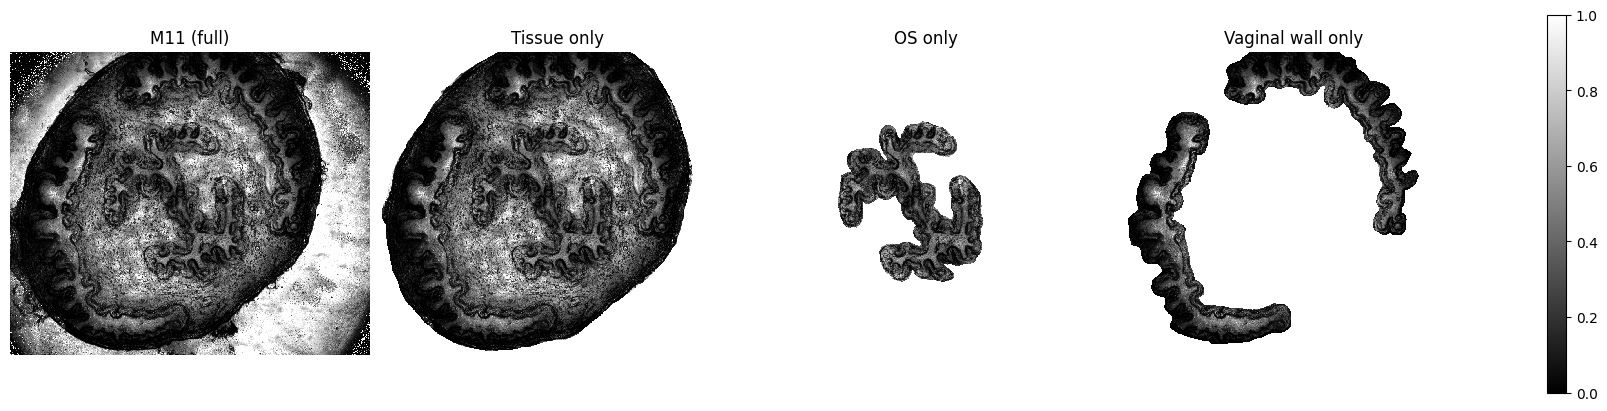

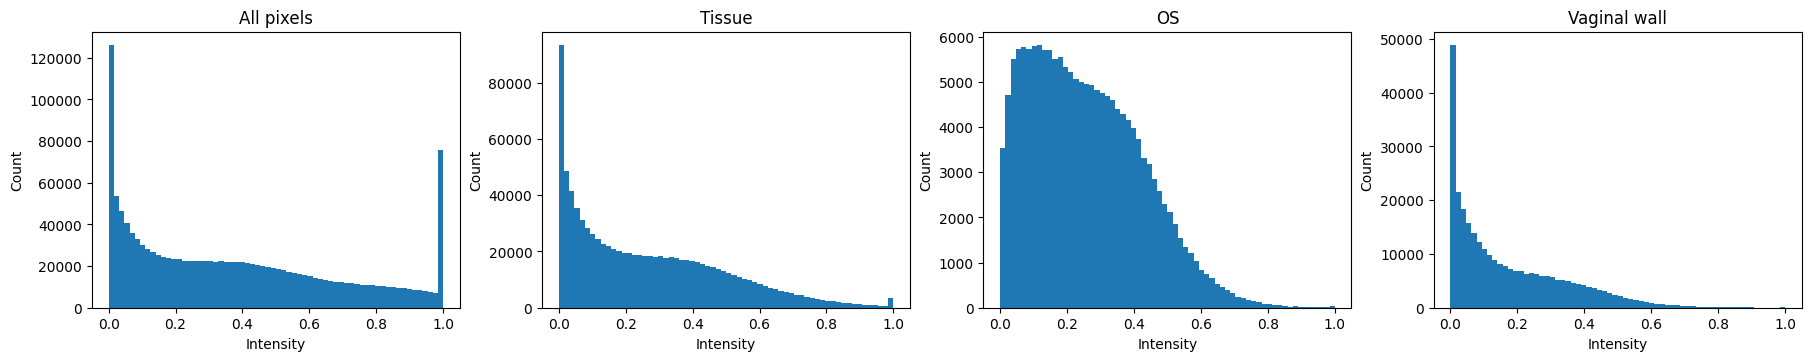

All: n=1377684, min=0.000, p25=0.098, median=0.322, p75=0.595, max=1.000, mean=0.377, std=0.307
Tissue: n=911081, min=0.000, p25=0.067, median=0.220, p75=0.421, max=1.000, mean=0.267, std=0.227
OS: n=163642, min=0.000, p25=0.120, median=0.238, p75=0.374, max=1.000, mean=0.258, std=0.167
Vaginal wall: n=296268, min=0.000, p25=0.034, median=0.120, p75=0.282, max=1.000, mean=0.175, std=0.170


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- Load ---
data = np.load('/Volumes/ep_ssd/MPL_Data/dani/Good Example/TRIMMM.npz', allow_pickle=True)

# Core arrays
M11 = data['nM11s']                  # shape (1078, 1278)
tissue = data['tissue_mask']         # shape (1078, 1278)
os = data['os_mask']                 # shape (1078, 1278)
vw = data['vaginal_wall_mask']       # shape (1078, 1278)

# Make sure masks are boolean
tissue = tissue.astype(bool)
os = os.astype(bool)
vw = vw.astype(bool)

# In case the image has NaNs/inf, replace for visualizing/hist stats
M11_clean = np.array(M11, dtype=float)
M11_clean[~np.isfinite(M11_clean)] = np.nan

def masked_image(img, mask, fill=np.nan):
    """Return an image where pixels outside mask are set to `fill`."""
    out = np.full_like(img, fill, dtype=float)
    out[mask] = img[mask]
    return out

# Prepare masked versions (NaNs outside the region so imshow ignores them)
M11_tissue = masked_image(M11_clean, tissue, fill=np.nan)
M11_os     = masked_image(M11_clean, os,     fill=np.nan)
M11_vw     = masked_image(M11_clean, vw,     fill=np.nan)

# --- Figure 1: masked grayscale views ---
fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
imgs = [
    ("M11 (full)", M11_clean),
    ("Tissue only", M11_tissue),
    ("OS only", M11_os),
    ("Vaginal wall only", M11_vw),
]

for ax, (title, arr) in zip(axes, imgs):
    im = ax.imshow(arr, cmap='gray', interpolation='nearest')
    ax.set_title(title)
    ax.axis('off')
fig.colorbar(im, ax=axes, fraction=0.02)  # colorbar scale follows the last imshow
plt.show()

# --- Figure 2: histograms per region (grayscale intensities) ---
def finite_vals(img, mask=None):
    if mask is None:
        vals = img[np.isfinite(img)]
    else:
        vals = img[mask & np.isfinite(img)]
    return vals

vals_all    = finite_vals(M11_clean)
vals_tissue = finite_vals(M11_clean, tissue)
vals_os     = finite_vals(M11_clean, os)
vals_vw     = finite_vals(M11_clean, vw)

# Choose common bins based on overall range
vmin = np.nanmin(M11_clean)
vmax = np.nanmax(M11_clean)
bins = 64

fig2, axes2 = plt.subplots(1, 4, figsize=(18, 3.5), constrained_layout=True)
for ax, (title, vals) in zip(
    axes2,
    [
        ("All pixels", vals_all),
        ("Tissue", vals_tissue),
        ("OS", vals_os),
        ("Vaginal wall", vals_vw),
    ],
):
    ax.hist(vals, bins=bins, range=(vmin, vmax))
    ax.set_title(title)
    ax.set_xlabel("Intensity")
    ax.set_ylabel("Count")
plt.show()

# --- Print summary stats ---
def stats(name, vals):
    if vals.size == 0:
        print(f"{name}: no pixels")
        return
    print(
        f"{name}: n={vals.size}, "
        f"min={np.nanmin(vals):.3f}, "
        f"p25={np.nanpercentile(vals,25):.3f}, "
        f"median={np.nanmedian(vals):.3f}, "
        f"p75={np.nanpercentile(vals,75):.3f}, "
        f"max={np.nanmax(vals):.3f}, "
        f"mean={np.nanmean(vals):.3f}, "
        f"std={np.nanstd(vals):.3f}"
    )

stats("All", vals_all)
stats("Tissue", vals_tissue)
stats("OS", vals_os)
stats("Vaginal wall", vals_vw)

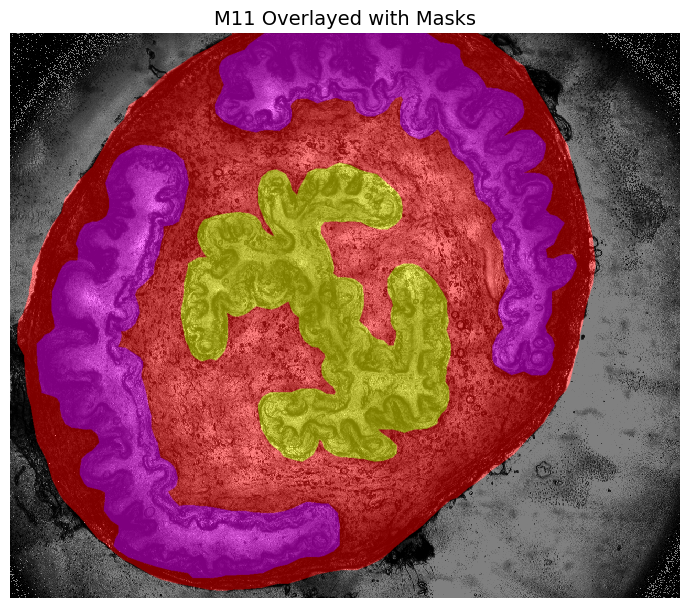

<Figure size 640x480 with 0 Axes>

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- Load data ---
data = np.load('/Volumes/ep_ssd/MPL_Data/dani/Good Example/TRIMMM.npz', allow_pickle=True)
M11 = data['nM11s']
tissue = data['tissue_mask'].astype(bool)
os = data['os_mask'].astype(bool)
vw = data['vaginal_wall_mask'].astype(bool)

# --- Normalize M11 for display ---
M11_norm = (M11 - np.nanmin(M11)) / (np.nanmax(M11) - np.nanmin(M11))

# --- Create RGB composite for overlay ---
overlay = np.stack([M11_norm]*3, axis=-1)  # grayscale base

# Assign color channels:
overlay[tissue, 0] = 1.0   # red for tissue
overlay[os, 1] = 1.0       # green for os
overlay[vw, 2] = 1.0       # blue for vaginal wall

# Optional: add transparency for a nice overlay effect
alpha = 0.5
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(M11_norm, cmap='gray', interpolation='nearest')
ax.imshow(np.dstack([
    tissue.astype(float),
    os.astype(float),
    vw.astype(float)
]), alpha=alpha)

ax.set_title("M11 Overlayed with Masks", fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

# Optional save: high-res for slides
plt.savefig('M11_overlay_for_slide.png', dpi=300, bbox_inches='tight')